### LeNet5

#### 一、网络架构
1. 输入层：32*32 的黑白图像
2. C1卷积层：6个卷积核，卷积核大小为5 $\times5$ ，输出根据输出公式$out= \frac{n - f + 2p}{s} + 1 = \frac{32-5+2*0}{2}+1 = 28$, 输出为$28\times 28 \times6$ 的特征图
3. S2池化层：2*2的池化核，步长为2，输出为$14\times 14 \times6$ 的特征图，执行下采样
4. C3卷积层：16个卷积核，卷积核大小为5 $\times5$，输出为$10\times10\times1$，输出为10*10*16的特征图
5. S4池化层：2 $\times2$的池化核，步长为2，输出为$5\times5\times16$的特征图，执行下采样
6. F5/F6全连接层：将提取出的局部特征平铺（Flatten），通过线性组合进行决策
7. 输出层：最后使用Softmax输出10个类别的概率

#### 二、为什么这样设计：
1. 局部理解（Local Connectivity）：卷积层不像全连接层那样一次性看所有像素，而是通过卷积核逐块扫描
2. 平移不变性：池化层可以识别最明显的信号
3. 降维与压缩：通过步幅和池化，模型在加深的同时减小了每一层的空间尺寸，平衡了计算效率和特征复杂率

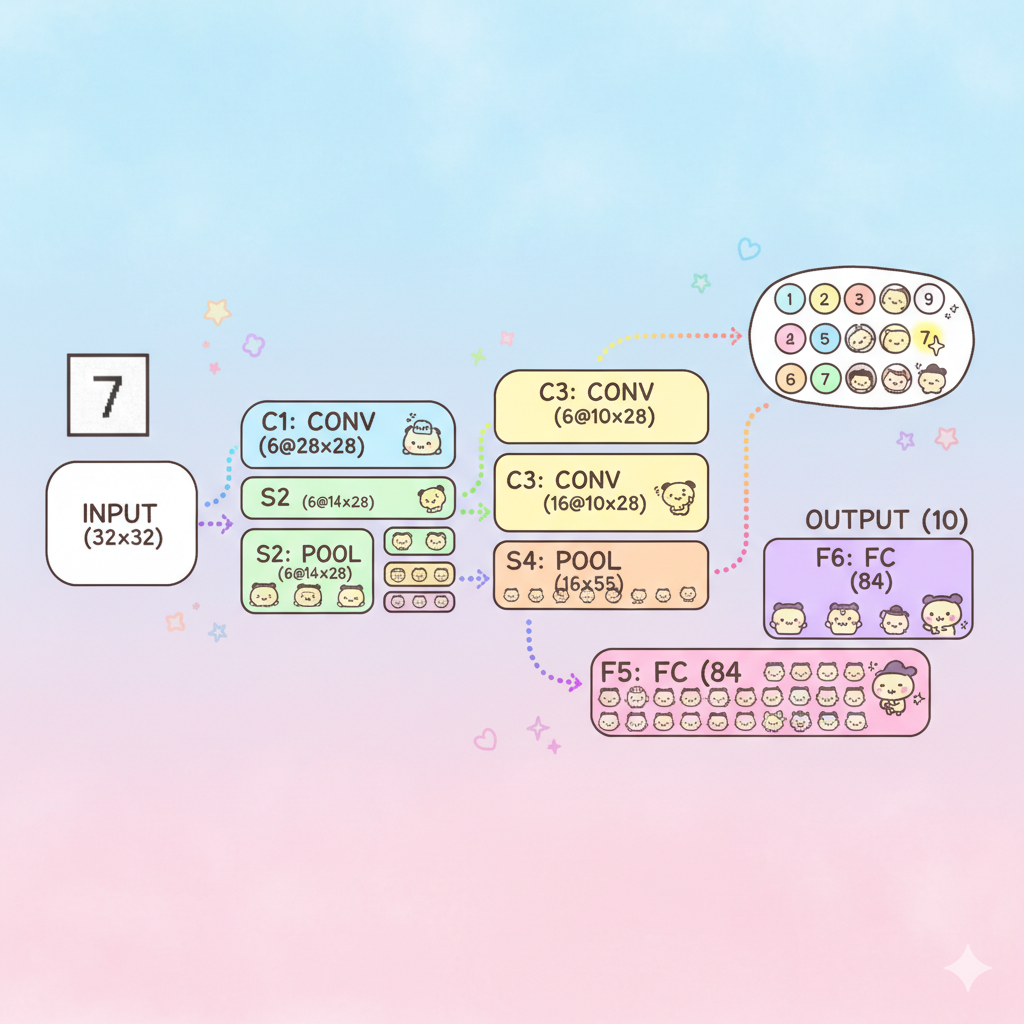

In [2]:
import torch
from torch import nn
from torchsummary import summary

In [3]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet,self).__init__()

    self.c1 = nn.Conv2d(in_channels = 1, out_channels = 6, kernel_size = 5,padding= 2)
    self.sig = nn.Sigmoid()
    self.s2 = nn.AvgPool2d(kernel_size = 2, stride = 2)
    self.c3 = nn.Conv2d(in_channels = 6, out_channels = 16, kernel_size = 5)
    self.s4 = nn.AvgPool2d(kernel_size = 2, stride = 2)

    self.flatten = nn.Flatten()
    self.f5 = nn.Linear(16*5*5,120)
    self.f6 = nn.Linear(120,84)
    self.f7 = nn.Linear(84,10)

  def forward(self,x):
    x = self.sig(self.c1(x))
    x = self.s2(x)
    x = self.sig(self.c3(x))
    x = self.s4(x)
    x = self.flatten(x)
    x = self.sig(self.f5(x))
    x = self.sig(self.f6(x))
    x = self.f7(x)
    return x

if __name__ == '__main__':
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = LeNet().to(device)
  print(summary(model,(1,28,28)))



----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             156
           Sigmoid-2            [-1, 6, 28, 28]               0
         AvgPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
           Sigmoid-5           [-1, 16, 10, 10]               0
         AvgPool2d-6             [-1, 16, 5, 5]               0
           Flatten-7                  [-1, 400]               0
            Linear-8                  [-1, 120]          48,120
           Sigmoid-9                  [-1, 120]               0
           Linear-10                   [-1, 84]          10,164
          Sigmoid-11                   [-1, 84]               0
           Linear-12                   [-1, 10]             850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
---------------------------------